## **House Price Prediction using Linear Regression**


**Objective:**  
To build and evaluate a Linear Regression model using the California Housing dataset and understand the complete machine learning workflow including data loading, exploration, preprocessing, training, prediction, and evaluation.

## Project Workflow

**Import Libraries → Load Dataset → EDA → Data Preparation → Train Model → Evaluate → Visualize → Save Model → Build UI**

Step 1: Install & Import Libraries

In [1]:
# Install required libraries (Colab usually has these pre-installed, but just in case)
!pip install pandas numpy scikit-learn matplotlib seaborn -q

# Import all libraries we'll need throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make plots look a bit nicer
sns.set(style="whitegrid")

Step 2: Load the Dataset

In [2]:
# Load the California Housing dataset built into scikit-learn
data = fetch_california_housing(as_frame=True)

# Combine features and target into a single DataFrame
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

# Preview the first few rows
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic info about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Step 3: Exploratory Data Analysis (EDA)

In [4]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
# Statistical summary of all columns
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


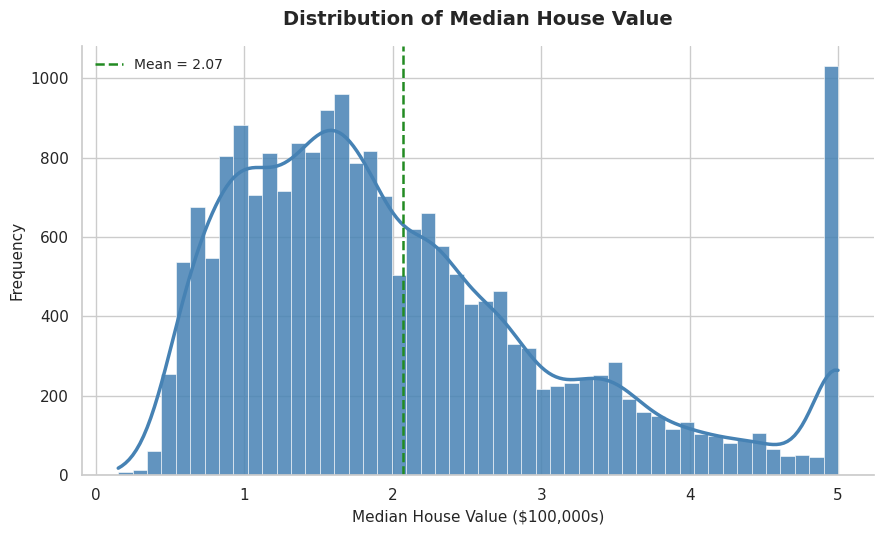

In [30]:
# Distribution of the target variable (Median House Value)
plt.figure(figsize=(9, 5.5))

sns.histplot(
    df['MedHouseVal'],
    bins=50,
    kde=True,
    color='steelblue',
    edgecolor='white',
    linewidth=0.4,
    alpha=0.85,
    line_kws={'linewidth': 2.5, 'color': 'darkorange'}
)

plt.title("Distribution of Median House Value", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Median House Value ($100,000s)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

mean_val = df['MedHouseVal'].mean()
plt.axvline(mean_val, color='forestgreen', linestyle='--', linewidth=1.8, label=f'Mean = {mean_val:.2f}')
plt.legend(frameon=False, fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

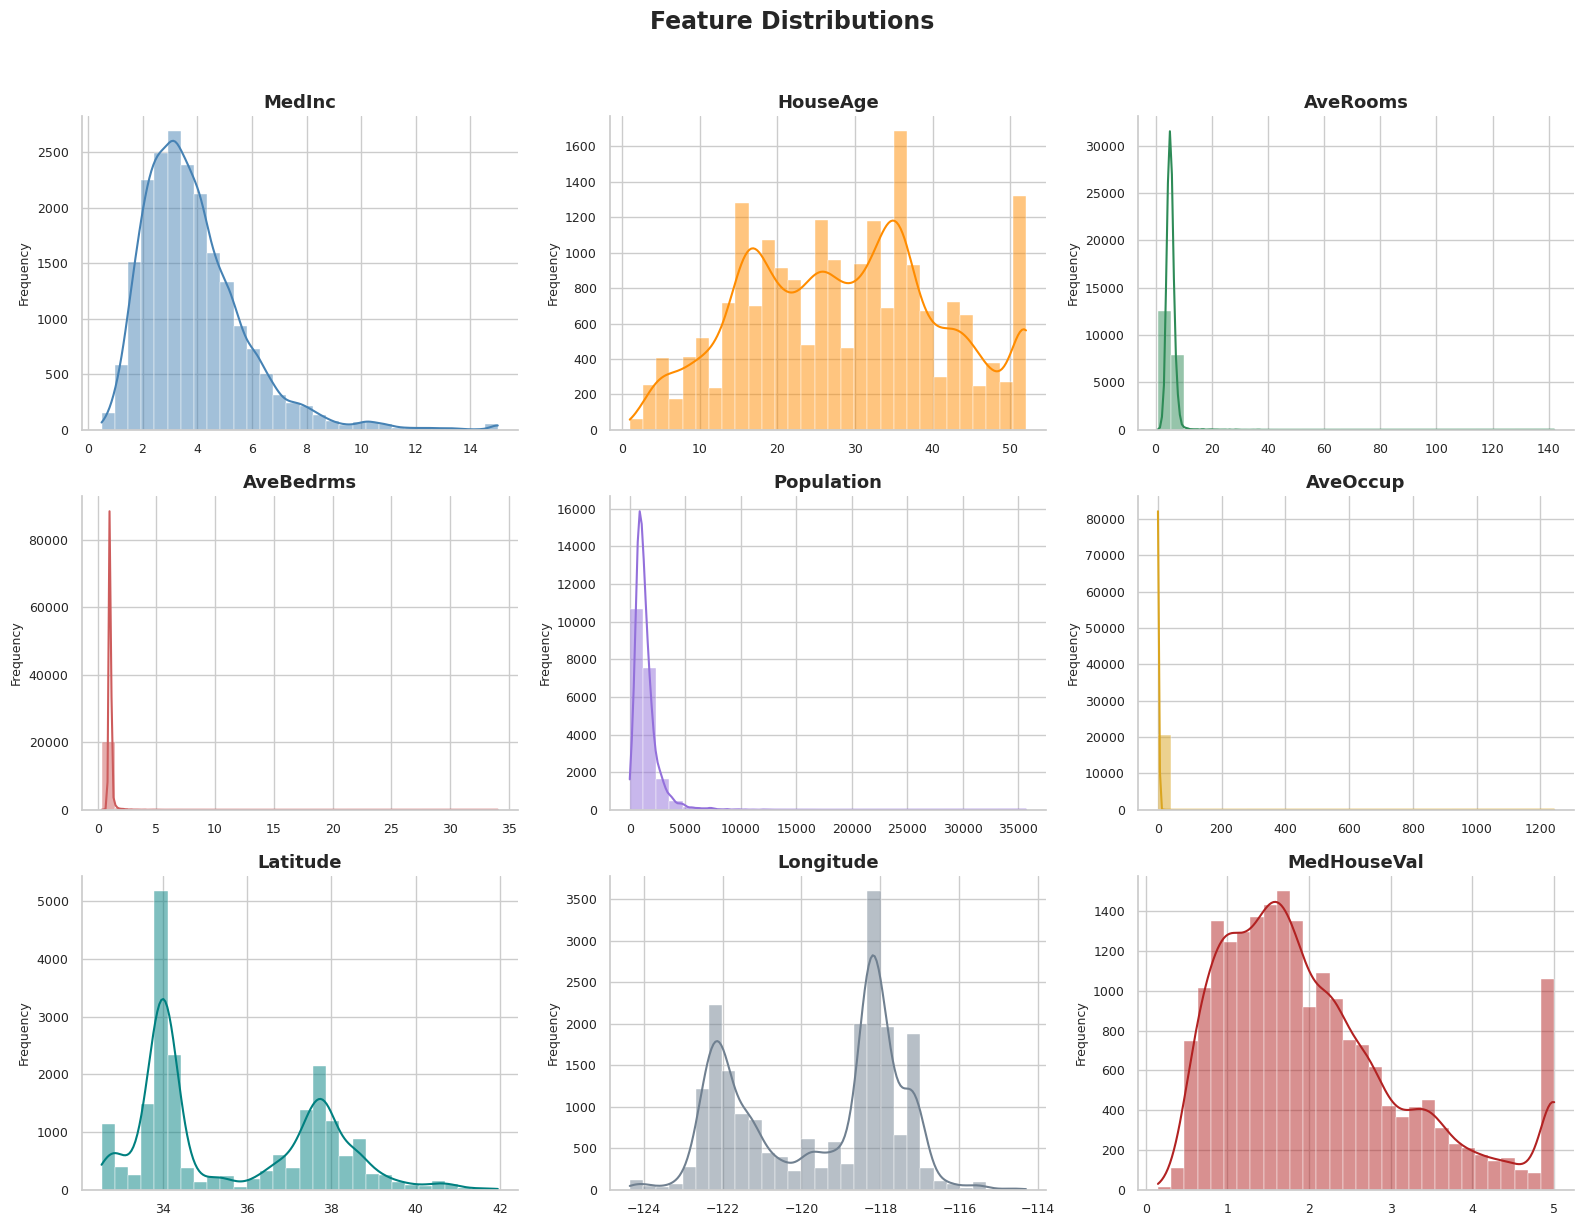

In [36]:
# Distribution of all features - cleaner, larger, better labeled version
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors_list = ['steelblue', 'darkorange', 'seagreen', 'indianred',
               'mediumpurple', 'goldenrod', 'teal', 'slategray', 'firebrick']

for i, col in enumerate(df.columns):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i],
                 color=colors_list[i], edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency", fontsize=9)
    axes[i].tick_params(labelsize=9)

plt.suptitle("Feature Distributions", fontsize=17, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

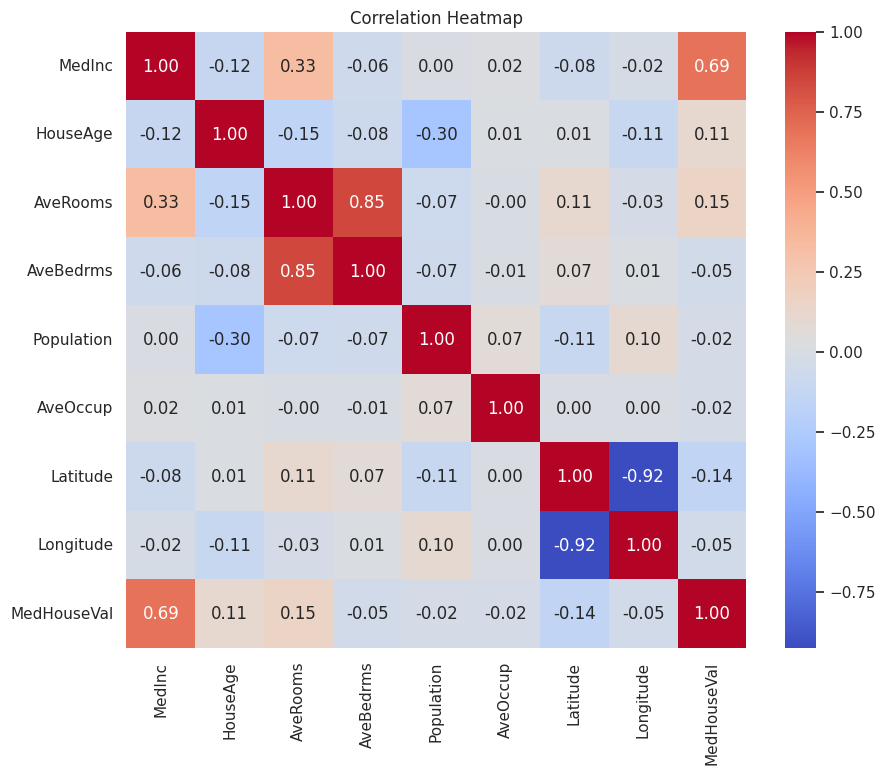

In [8]:
# Correlation heatmap - shows which features relate to the target
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Check correlation of each feature specifically with the target variable
print("Correlation with MedHouseVal (target):")
print(corr['MedHouseVal'].sort_values(ascending=False))

Correlation with MedHouseVal (target):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


Step 4: Select Features & Split Data

In [10]:
# Separate features (X) and target (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (16512, 8)
Testing set size: (4128, 8)


Step 5: Train the Model & Evaluate

In [11]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): {mae:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")
print(f"R²   (R-squared Score): {r2:.3f}")

MAE  (Mean Absolute Error): 0.533
RMSE (Root Mean Squared Error): 0.746
R²   (R-squared Score): 0.576


In [37]:
# Look at the model's learned coefficients (how much each feature affects price)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Model Intercept:", model.intercept_)
coeff_df

Model Intercept: -37.02327770606409


,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


Step 6: Plot Predicted vs Actual & Residuals

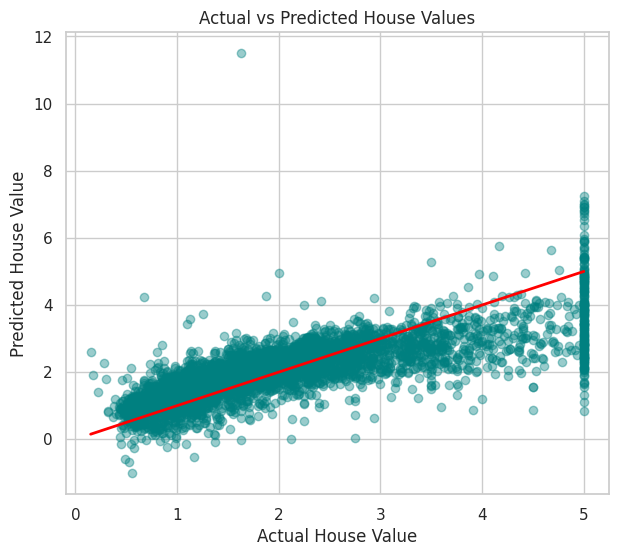

In [13]:
# Plot 1: Actual vs Predicted scatter plot
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.show()

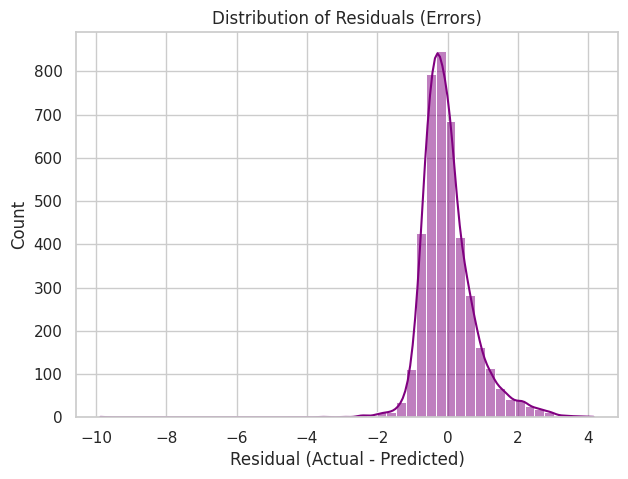

In [14]:
# Plot 2: Residuals plot (errors = actual - predicted)
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

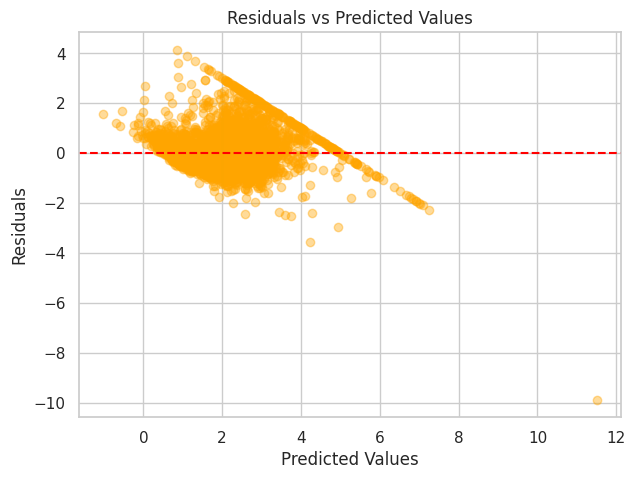

In [15]:
# Plot 3: Residuals vs Predicted values (checks for patterns in errors)
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.4, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

Step 8 : Save the Model as a Pickle File

In [38]:
# Save the trained model to a pickle file
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as house_price_model.pkl")

# To download this file from Colab to your computer:
from google.colab import files
files.download('house_price_model.pkl')

Model saved as house_price_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 9 : Small UI Script to Predict on New Inputs

In [17]:
# Load the model back (simulates using it later, e.g. in a fresh session)
with open('house_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

def predict_house_price(MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude):
    """
    Simple function-based 'UI' to predict median house value
    given the 8 California Housing features.
    """
    input_data = pd.DataFrame([{
        'MedInc': MedInc,
        'HouseAge': HouseAge,
        'AveRooms': AveRooms,
        'AveBedrms': AveBedrms,
        'Population': Population,
        'AveOccup': AveOccup,
        'Latitude': Latitude,
        'Longitude': Longitude
    }])
    prediction = loaded_model.predict(input_data)[0]
    print(f"Predicted Median House Value: ${prediction*100000:.2f}")
    return prediction

# Example usage — try changing these values
predict_house_price(
    MedInc=5.0,
    HouseAge=25,
    AveRooms=6.0,
    AveBedrms=1.0,
    Population=1000,
    AveOccup=3.0,
    Latitude=34.0,
    Longitude=-118.0
)

Predicted Median House Value: $239840.67


np.float64(2.398406675742045)

Step 10 : Interactive UI Widget

In [35]:
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown

# ---------- Title & Explanation ----------
title_html = HTML("""
<h2>🏠 California House Price Estimator</h2>
<p>This app uses a <b>Machine Learning model</b> (Linear Regression) trained on real housing data
from California to estimate the </p>
<p><b>median house value in a neighborhood</b>,</p>
based on a few details about that area.</p>
<p>Just fill in the details below and click <b>Predict Price</b> to see the estimate.</p>
<hr>
""")
display(title_html)

# ---------- Input Widgets  ----------
style = {'description_width': '260px'}
layout = widgets.Layout(width='430px')

med_inc = widgets.FloatText(
    value=5.0, description='Average Income in area ($10,000s) [0.5–15]:', style=style, layout=layout
)
house_age = widgets.FloatText(
    value=25, description='Average Age of Houses (years) [1–52]:', style=style, layout=layout
)
ave_rooms = widgets.FloatText(
    value=6.0, description='Average Rooms per House [1–20]:', style=style, layout=layout
)
ave_bedrms = widgets.FloatText(
    value=1.0, description='Average Bedrooms per House [0.3–5]:', style=style, layout=layout
)
population = widgets.FloatText(
    value=1000, description='Population of the area [3–35,000]:', style=style, layout=layout
)
ave_occup = widgets.FloatText(
    value=3.0, description='Average People per Household [0.5–10]:', style=style, layout=layout
)
latitude = widgets.FloatText(
    value=34.0, description='Latitude (location, north–south) [32.5–42]:', style=style, layout=layout
)
longitude = widgets.FloatText(
    value=-118.0, description='Longitude (location, east–west) [-124.3 to -114.3]:', style=style, layout=layout
)

button = widgets.Button(description="🔮 Predict Price", button_style='success', layout=widgets.Layout(width='200px'))
output = widgets.Output()

def on_button_click(b):
    with output:
        output.clear_output()
        result = predict_house_price(
            med_inc.value, house_age.value, ave_rooms.value, ave_bedrms.value,
            population.value, ave_occup.value, latitude.value, longitude.value
        )

button.on_click(on_button_click)

display(med_inc, house_age, ave_rooms, ave_bedrms, population, ave_occup, latitude, longitude, button, output)

FloatText(value=5.0, description='Average Income in area ($10,000s) [0.5–15]:', layout=Layout(width='430px'), …

FloatText(value=25.0, description='Average Age of Houses (years) [1–52]:', layout=Layout(width='430px'), style…

FloatText(value=6.0, description='Average Rooms per House [1–20]:', layout=Layout(width='430px'), style=Descri…

FloatText(value=1.0, description='Average Bedrooms per House [0.3–5]:', layout=Layout(width='430px'), style=De…

FloatText(value=1000.0, description='Population of the area [3–35,000]:', layout=Layout(width='430px'), style=…

FloatText(value=3.0, description='Average People per Household [0.5–10]:', layout=Layout(width='430px'), style…

FloatText(value=34.0, description='Latitude (location, north–south) [32.5–42]:', layout=Layout(width='430px'),…

FloatText(value=-118.0, description='Longitude (location, east–west) [-124.3 to -114.3]:', layout=Layout(width…

Button(button_style='success', description='🔮 Predict Price', layout=Layout(width='200px'), style=ButtonStyle(…

Output()